In [15]:
import pandas as pd
import numpy as np

import yfinance as yf
#import mplfinance as mpf

from datetime import datetime

from stock_data_functions import *	# ESTE ES EL OTRO ARCHIVO PY CON LAS FUNCIONES	

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

In [16]:
# EXPORT CSV FILES ----------------------------------------------

path_out_01 = "C:/Users/SebastiánSilva/OneDrive - RSM SPAIN SERVICIOS ADMINISTRATIVOS SL/Escritorio/RSM/Personal/_Proyectos-Personales/Python DEGIRO/OUTPUT/DEGIRO-CSV-ALL.csv"		# EXPORTAR FICHERO
df_degiro = pd.read_csv(path_out_01, sep=',', decimal=".")

path_out_02 = "C:/Users/SebastiánSilva/OneDrive - RSM SPAIN SERVICIOS ADMINISTRATIVOS SL/Escritorio/RSM/Personal/_Proyectos-Personales/Python DEGIRO//OUTPUT/DEGIRO-CSV-PORTFOLIO-DF_FINAL_TICKER.csv"	# EXPORTAR FICHERO
df_portfolio_ticker = pd.read_csv(path_out_02, sep=',', decimal=".")

path_out_03 = "C:/Users/SebastiánSilva/OneDrive - RSM SPAIN SERVICIOS ADMINISTRATIVOS SL/Escritorio/RSM/Personal/_Proyectos-Personales/Python DEGIRO//OUTPUT/DEGIRO-CSV-PORTFOLIO-DF_FINAL.csv"	# EXPORTAR FICHERO
portfolio = pd.read_csv(path_out_03, sep=',', decimal=".")

path_out_04 = "C:/Users/SebastiánSilva/OneDrive - RSM SPAIN SERVICIOS ADMINISTRATIVOS SL/Escritorio/RSM/Personal/_Proyectos-Personales/Python DEGIRO//OUTPUT/DEGIRO-CSV-ALL_STOCK_DATA.csv"		# EXPORTAR FICHERO
all_stocks = pd.read_csv(path_out_04, sep=',', decimal=".")


In [17]:
df_degiro.head()

,Unnamed: 0,date,ticker,tipo_movimiento,movimiento,importe,num_acciones,price,moneda,description,fx_rate,importe_EUR,price_EUR
0,0,2021-07-27,Deposito,DEPOSITOS,Deposito,1000.00,0.0,NaN,EUR,flatex Deposit,0.85,1000.00,NaN
1,1,2021-07-27,VUSA.MI,COMPRA ACCIONES,VANGUARD S&P500,-993.85,14.0,70.989,EUR,"Compra 14 Vanguard S&P 500 UCITS ETF USD@70,98...",0.85,-993.85,70.99
2,2,2021-08-03,Gastos,COMISION,NaN,-2.49,0.0,NaN,EUR,Comisión de conectividad con el mercado 2021 (...,0.84,-2.49,NaN
3,3,2021-08-17,Deposito,DEPOSITOS,Deposito,1003.00,0.0,NaN,EUR,flatex Deposit,0.85,1003.00,NaN
4,4,2021-08-17,VUSA.MI,COMPRA ACCIONES,VANGUARD S&P500,-1006.32,14.0,71.880,EUR,"Compra 14 Vanguard S&P 500 UCITS ETF USD@71,88...",0.85,-1006.32,71.88


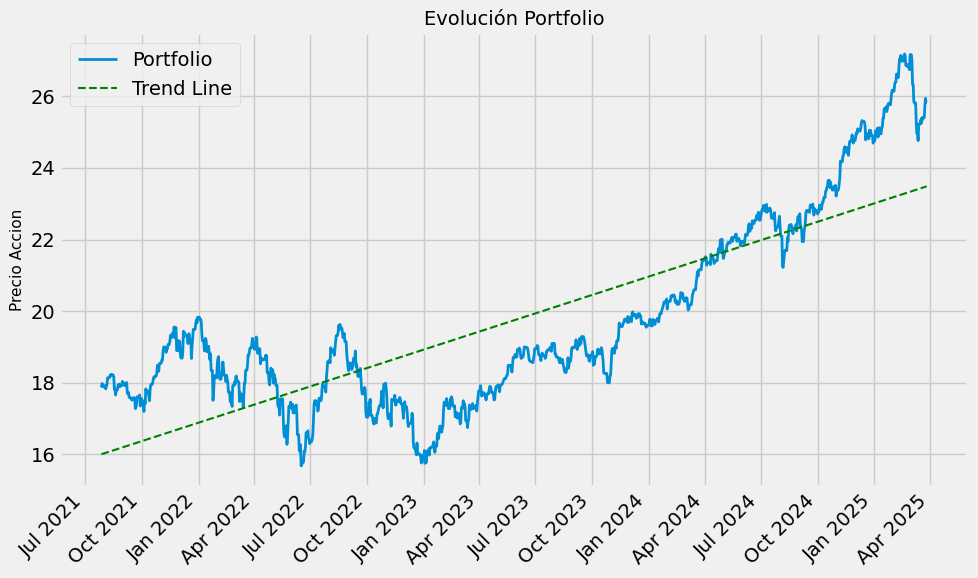

In [18]:
# PLOT PORTFOLIO ----------------------------------------------------------

# Create the figure
fig = plt.figure()
fig.set_size_inches(10, 6)
plt.style.use('fivethirtyeight')

# Filter data for the specific ticker
ticker = 'VUSA.MI'
compare_stock = all_stocks[all_stocks['ticker'] == ticker]

# Ensure the 'date' column is in datetime format
portfolio['date'] = pd.to_datetime(portfolio['date'])

# Plot the portfolio data
plt.plot(portfolio['date'], portfolio['acc_price'], linewidth=2.0, label='Portfolio')

# Calculate the trend line using polyfit (1st degree polynomial for linear fit)
dates = mdates.date2num(portfolio['date'])  # Convert dates to numerical format
trend_params = np.polyfit(dates, portfolio['acc_price'], 1)  # Fit a linear model (degree 1)
trend_line = np.polyval(trend_params, dates)  # Evaluate the trend line

# Plot the trend line
plt.plot(portfolio['date'], trend_line, linestyle='--', linewidth=1.5, color='green', label='Trend Line')

# Set title and labels
plt.title('Evolución Portfolio', fontsize=14)
plt.ylabel('Precio Accion', fontsize=11)

# Format x-axis to show one tick per quarter
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # Ticks for each quarter
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as "Month Year" (e.g., Jan 2023)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()



C:\Users\SebastiánSilva\AppData\Local\Temp\ipykernel_35016\581682031.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  compare_stock['date'] = pd.to_datetime(compare_stock['date'])


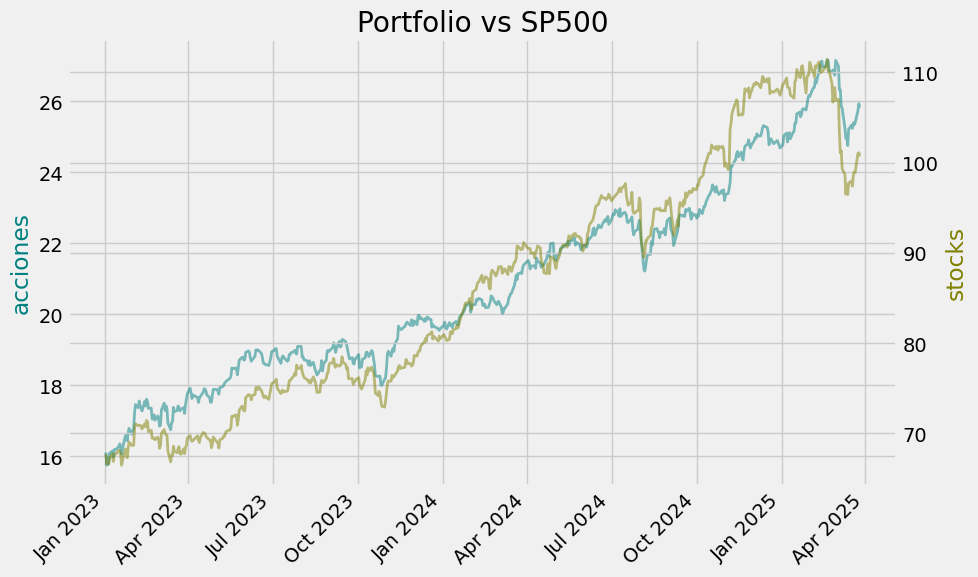

In [19]:
# PLOT PORTFOLIO VS SP500 ----------------------------------------------------------

# Ensure the 'date' column is in datetime format in both dataframes
portfolio['date'] = pd.to_datetime(portfolio['date'])
compare_stock['date'] = pd.to_datetime(compare_stock['date'])

# Merge the dataframes based on 'date'
df = pd.merge(portfolio[['date', 'acc_price']], compare_stock[['date', 'Close']], on='date', how='left')

# Drop rows with missing data
df = df.dropna()

# Filter the data to include only rows from 2023 onwards <----------- FILTER BY YEAR
df = df[df['date'].dt.year >= 2023]

# Extract the date, accumulated price, and stock price
date = df['date']
acc_price = df['acc_price']
close = df['Close']

# Create the figure and axis objects
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot the accumulated price and stock price
ax1.plot(date, acc_price, color='teal', linewidth=2.0, label='acciones', alpha=0.5)
ax2.plot(date, close, color='olive', linewidth=2.0, label='stocks', alpha=0.5)

# Set the labels for the axes
ax1.set_ylabel('acciones', color='teal')
ax2.set_ylabel('stocks', color='olive')

# Format the x-axis to show one tick per quarter (January, April, July, October)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # Start of each quarter
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as "Month Year" (e.g., Jan 2023)

# Rotate x-axis labels for better readability
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Title and layout
plt.title('Portfolio vs SP500')
plt.tight_layout()

# Show the plot
plt.show()


C:\Users\SebastiánSilva\AppData\Local\Temp\ipykernel_35016\2471976799.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dividends['date'] = pd.to_datetime(df_dividends['date'])
C:\Users\SebastiánSilva\AppData\Local\Temp\ipykernel_35016\2471976799.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dividends['acc_importe'] = df_dividends['importe'].cumsum()


<Figure size 1000x600 with 0 Axes>

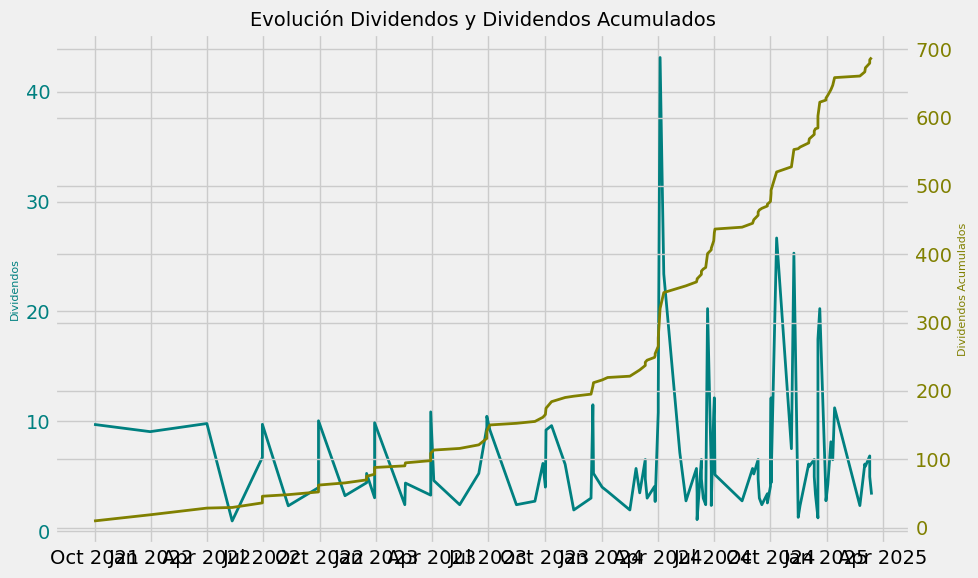

In [20]:
# PLOT DIVIDENDOS ----------------------------------------------------------

# Create the figure
fig = plt.figure()
fig.set_size_inches(10, 6)
plt.style.use('fivethirtyeight')

# Filter data for the specific tipo_mov (DIVIDENDO)
tipo_mov = 'DIVIDENDO'
df_dividends = df_degiro[df_degiro['tipo_movimiento'] == tipo_mov]

# Ensure the 'date' column is in datetime format
df_dividends['date'] = pd.to_datetime(df_dividends['date'])

# Calculate the accumulated amount (cumulative sum)
df_dividends['acc_importe'] = df_dividends['importe'].cumsum()

# Create a figure and two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the original dividend data
ax1.plot(df_dividends['date'], df_dividends['importe'], color='teal', linewidth=2.0, label='Dividendos')
ax1.set_ylabel('Dividendos', fontsize=8, color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

# Create a secondary y-axis for the accumulated values
ax2 = ax1.twinx()
ax2.plot(df_dividends['date'], df_dividends['acc_importe'], color='olive', linewidth=2.0, label='Dividendos Acumulados')
ax2.set_ylabel('Dividendos Acumulados', fontsize=8, color='olive')
ax2.tick_params(axis='y', labelcolor='olive')

# Title and x-axis formatting
plt.title('Evolución Dividendos y Dividendos Acumulados', fontsize=14)

# Format x-axis to show only one label per quarter (January, April, July, October)
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))  # Ticks for each quarter
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as "Month Year" (e.g., Jan 2023)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

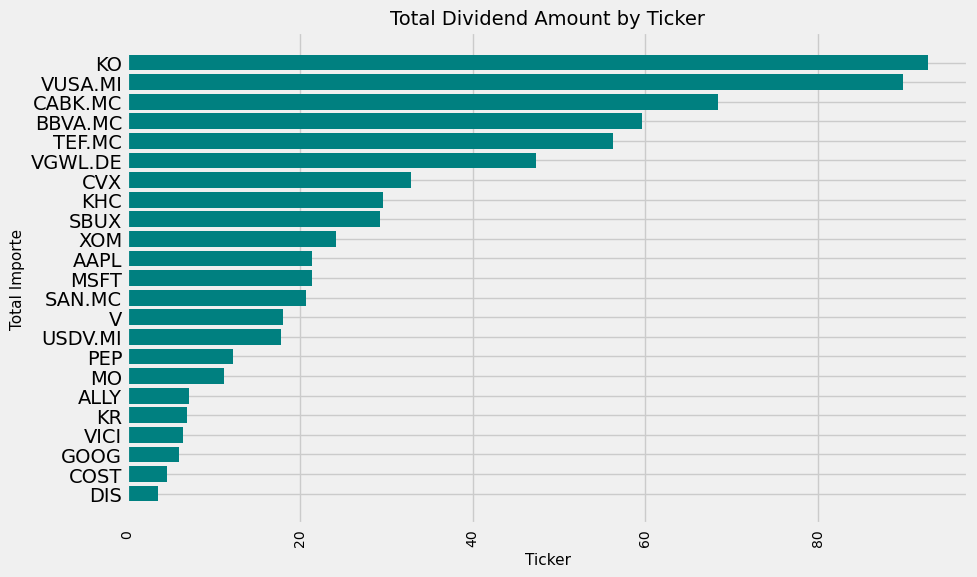

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by 'ticker' and sum the 'importe'
df_sum = df_dividends.groupby('ticker')['importe'].sum().reset_index()

# Sort the results by 'importe' in descending order
df_sum = df_sum.sort_values(by='importe', ascending=True)

# Plot the bar graph
plt.figure(figsize=(10, 6))
bars = plt.barh(df_sum['ticker'], df_sum['importe'], color='teal')

# Set title and labels
plt.title('Total Dividend Amount by Ticker', fontsize=14)
plt.xlabel('Ticker', fontsize=11)
plt.ylabel('Total Importe', fontsize=11)

# Rotate ticker labels to vertical and make them smaller
plt.xticks(rotation=90, fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()


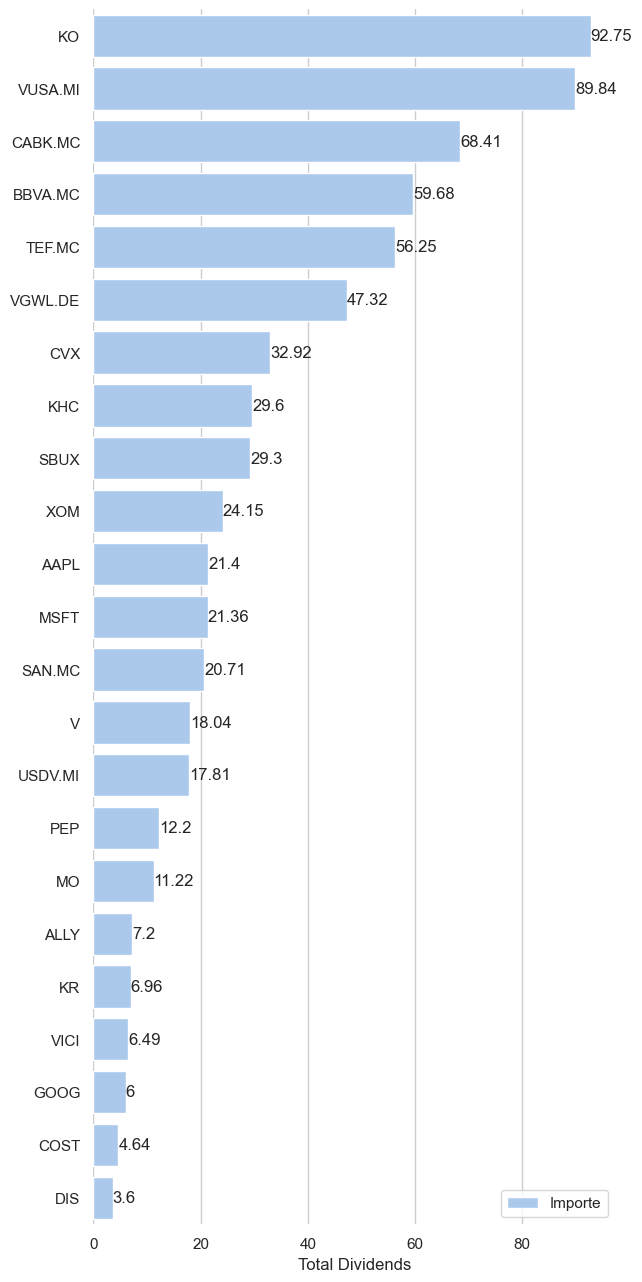

In [ ]:
sns.set_theme(style="whitegrid")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 15))

# Group by 'ticker' and sum the 'importe'
df_sum = df_dividends.groupby('ticker')['importe'].sum().reset_index()

# Sort the results by 'importe' in descending order
df_sum = df_sum.sort_values(by='importe', ascending=False)

# Plot the total crashes
sns.set_color_codes("pastel")
sns.barplot(x="importe", y="ticker", data=df_sum,
            label="Importe", color="b")

# Add a legend and informative axis label
ax.legend(ncol=2, loc="lower right", frameon=True)
ax.set(ylabel="",
       xlabel="Total Dividends")

for container in ax.containers:
    ax.bar_label(container)

sns.despine(left=True, bottom=True)